# Reproducing Figure 5: Mess3 Belief State Geometry in Transformer Residual Streams

**Paper**: "Transformers Represent Belief State Geometry in their Residual Stream"
(Shai, Marzen, Teixeira, Oldenziel, Riechers — NeurIPS 2024, arXiv:2405.15943v3)

This notebook reproduces the Mess3 experiment (Figure 5, Figure 6) end-to-end:
1. Define the Mess3 HMM with the paper's exact parameters (Appendix A.3)
2. Compute the ground-truth belief state geometry via the Mixed-State Presentation
3. Train a transformer on Mess3-generated data (Appendix A.6)
4. Extract residual stream activations and run linear regression to find the belief simplex
5. Compare the learned geometry to ground truth
6. Run controls (cross-validation, shuffle) to verify nontriviality

In [1]:
import warnings
warnings.filterwarnings('ignore')

import itertools
import jax
import jax.numpy as jnp
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformer_lens import HookedTransformer, HookedTransformerConfig

from simplexity.generative_processes.transition_matrices import mess3
from simplexity.generative_processes.hidden_markov_model import HiddenMarkovModel
from simplexity.generative_processes.mixed_state_presentation import (
    MixedStateTreeGenerator,
    SearchAlgorithm,
)
from simplexity.generative_processes.torch_generator import generate_data_batch
from simplexity.analysis.linear_regression import linear_regression

# ── Mess3 process parameters (Appendix A.3) ──
MESS3_X = 0.05
MESS3_A = 0.85

# ── Transformer architecture (Appendix A.6) ──
N_CTX = 10
D_MODEL = 64
D_HEAD = 8
N_HEADS = 1        # paper: "1 attention head in each of 4 layers"
N_LAYERS = 4
D_MLP = 256
ACT_FN = 'relu'

# ── Training (Appendix A.6) ──
BATCH_SIZE = 64
LEARNING_RATE = 0.01
SEQUENCE_LEN = N_CTX + 1   # generates N_CTX+1 tokens -> N_CTX inputs / labels

# Paper uses 1_000_000 steps. Reduce for faster runs; increase for paper quality.
NUM_STEPS = 50_000

# ── Analysis ──
MSP_DEPTH = 8               # MSP tree depth for ground-truth visualization
SEED = 42

# ── Derived ──
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Training steps: {NUM_STEPS:,}  (paper uses 1,000,000)')

Device: cpu
Training steps: 50,000  (paper uses 1,000,000)


## 1. Define and Verify the Mess3 Process (Appendix A.3)

The Mess3 process is a 3-state HMM with vocabulary {A, B, C}. The paper specifies
exact transition matrices in Appendix A.3. We verify our construction matches to
machine precision.

In [2]:
transition_matrices = mess3(MESS3_X, MESS3_A)

# ── Paper's exact matrices (Appendix A.3) ──
expected_T_A = jnp.array([
    [0.765,   0.00375, 0.00375],
    [0.0425,  0.0675,  0.00375],
    [0.0425,  0.00375, 0.0675 ],
])
expected_T_B = jnp.array([
    [0.0675,  0.0425,  0.00375],
    [0.00375, 0.765,   0.00375],
    [0.00375, 0.0425,  0.0675 ],
])
expected_T_C = jnp.array([
    [0.0675,  0.00375, 0.0425 ],
    [0.00375, 0.0675,  0.0425 ],
    [0.00375, 0.00375, 0.765  ],
])

assert jnp.allclose(transition_matrices[0], expected_T_A, atol=1e-10), \
    f'T^(A) MISMATCH:\n{transition_matrices[0]}'
assert jnp.allclose(transition_matrices[1], expected_T_B, atol=1e-10), \
    f'T^(B) MISMATCH:\n{transition_matrices[1]}'
assert jnp.allclose(transition_matrices[2], expected_T_C, atol=1e-10), \
    f'T^(C) MISMATCH:\n{transition_matrices[2]}'

# Verify stochasticity: rows of T = sum_x T^(x) must sum to 1
T_net = transition_matrices.sum(axis=0)
row_sums = T_net.sum(axis=1)
assert jnp.allclose(row_sums, 1.0, atol=1e-10), f'Row sums: {row_sums}'

print('PASS: All three transition matrices match paper Appendix A.3 exactly.')
print(f'PASS: Net transition matrix row sums = {row_sums}')
print(f'\nT^(A) =\n{np.array(transition_matrices[0])}')
print(f'\nT^(B) =\n{np.array(transition_matrices[1])}')
print(f'\nT^(C) =\n{np.array(transition_matrices[2])}')

PASS: All three transition matrices match paper Appendix A.3 exactly.
PASS: Net transition matrix row sums = [1. 1. 1.]

T^(A) =
[[0.765   0.00375 0.00375]
 [0.0425  0.0675  0.00375]
 [0.0425  0.00375 0.0675 ]]

T^(B) =
[[0.0675  0.0425  0.00375]
 [0.00375 0.765   0.00375]
 [0.00375 0.0425  0.0675 ]]

T^(C) =
[[0.0675  0.00375 0.0425 ]
 [0.00375 0.0675  0.0425 ]
 [0.00375 0.00375 0.765  ]]


## 2. Ground-Truth Belief State Geometry (Mixed-State Presentation)

The mixed-state presentation (MSP) describes how an optimal observer updates its
beliefs over the HMM's hidden states as it observes tokens. Each belief state is a
point in the 2-simplex (probability distribution over 3 states). The MSP of Mess3
has an intricate **fractal** structure — this is the geometry we expect the
transformer to learn.

Vocab size: 3  |  Num states: 3
Stationary distribution: [0.3333335  0.33333328 0.3333332 ]


MSP tree nodes: 9841
Non-zero-probability belief states: 9841
PASS: All MSP belief states sum to 1.


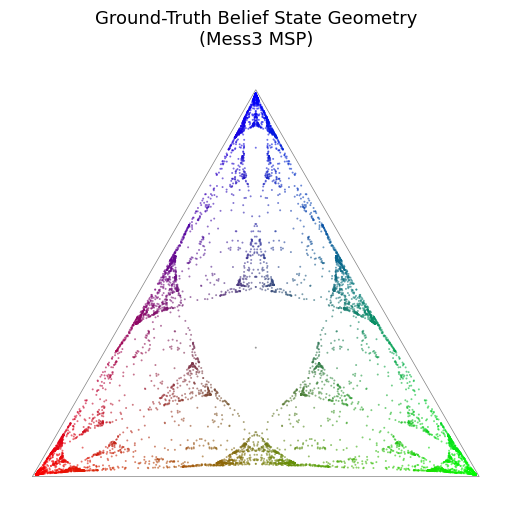

In [3]:
hmm = HiddenMarkovModel(transition_matrices)
print(f'Vocab size: {hmm.vocab_size}  |  Num states: {hmm.num_states}')
print(f'Stationary distribution: {np.array(hmm.initial_state)}')
assert jnp.allclose(jnp.sum(hmm.initial_state), 1.0, atol=1e-6), 'Initial state does not sum to 1'

# ── Build MSP tree ──
tree_gen = MixedStateTreeGenerator(ghmm=hmm, max_sequence_length=MSP_DEPTH)
msp_tree = tree_gen.generate(SearchAlgorithm.BREADTH_FIRST)
print(f'MSP tree nodes: {len(msp_tree)}')

# Collect belief states for plotting
belief_states_gt = []
for seq, node_val in msp_tree.nodes.items():
    prob, bs = node_val
    if prob > 1e-12:
        belief_states_gt.append(bs)
belief_states_gt = np.array(belief_states_gt)
print(f'Non-zero-probability belief states: {len(belief_states_gt)}')

# Sanity: all belief states should sum to 1
bs_sums = belief_states_gt.sum(axis=1)
assert np.allclose(bs_sums, 1.0, atol=1e-4), \
    f'Belief state sum range: [{bs_sums.min():.6f}, {bs_sums.max():.6f}]'
print('PASS: All MSP belief states sum to 1.')

# ── Helper: plot points in the 2-simplex ──
def simplex_to_xy(bs):
    """Barycentric -> Cartesian for an equilateral triangle."""
    x = bs[:, 1] + 0.5 * bs[:, 2]
    y = (np.sqrt(3) / 2) * bs[:, 2]
    return x, y

def plot_simplex(bs, title, ax, colors=None, s=1, alpha=0.5):
    x, y = simplex_to_xy(bs)
    c = np.clip(bs, 0, 1) if colors is None else np.clip(colors, 0, 1)
    ax.scatter(x, y, c=c, s=s, alpha=alpha, edgecolors='none')
    tri = plt.Polygon([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]],
                       fill=False, edgecolor='gray', lw=0.5)
    ax.add_patch(tri)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 0.95)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13)
    ax.axis('off')

# ── Plot ground-truth belief geometry (Figure 5B) ──
fig, ax = plt.subplots(figsize=(6, 5.2))
plot_simplex(belief_states_gt, 'Ground-Truth Belief State Geometry\n(Mess3 MSP)', ax, s=2, alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Initialize Transformer (Appendix A.6)

Architecture from the paper: context window 10, d_model=64, d_head=8,
n_heads=1, 4 layers, MLP dim 256, ReLU, layer normalization.
TransformerLens `HookedTransformer` is used (as in the paper).

In [4]:
torch.manual_seed(SEED)

# The paper specifies n_heads=1, d_head=8, d_model=64.
# TransformerLens allows d_head * n_heads != d_model (attention bottleneck).
# If this combination is rejected, we fall back to n_heads=8 and note it.
try:
    tl_cfg = HookedTransformerConfig(
        n_ctx=N_CTX, d_model=D_MODEL, d_head=D_HEAD, n_heads=N_HEADS,
        n_layers=N_LAYERS, d_mlp=D_MLP, d_vocab=hmm.vocab_size,
        act_fn=ACT_FN, normalization_type='LN', device=DEVICE, seed=SEED,
    )
    model = HookedTransformer(tl_cfg)
    print(f'Model created with paper config: n_heads={N_HEADS}, d_head={D_HEAD}')
except Exception as e:
    print(f'Paper config failed ({e}); using n_heads=8 (d_model/d_head = 64/8).')
    N_HEADS = 8
    tl_cfg = HookedTransformerConfig(
        n_ctx=N_CTX, d_model=D_MODEL, d_head=D_HEAD, n_heads=N_HEADS,
        n_layers=N_LAYERS, d_mlp=D_MLP, d_vocab=hmm.vocab_size,
        act_fn=ACT_FN, normalization_type='LN', device=DEVICE, seed=SEED,
    )
    model = HookedTransformer(tl_cfg)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')
print(f'd_model={tl_cfg.d_model}  d_head={tl_cfg.d_head}  n_heads={tl_cfg.n_heads}  '
      f'n_layers={tl_cfg.n_layers}  d_mlp={tl_cfg.d_mlp}  n_ctx={tl_cfg.n_ctx}')

Model created with paper config: n_heads=1, d_head=8
Parameters: 143,075
d_model=64  d_head=8  n_heads=1  n_layers=4  d_mlp=256  n_ctx=10


## 4. Train the Transformer

Paper uses SGD with lr=0.01, batch size 64, for 1,000,000 steps.
Each step generates a fresh batch of 64 sequences from the stationary distribution.
The loss is cross-entropy on next-token prediction.

Activation analysis is run at checkpoints to track the emergence of belief
state geometry over training (reproducing Figure 6A/D).

In [5]:
# ── Precompute exhaustive analysis data (paper Sec 2.3: "all possible input sequences") ──
all_seqs_np = np.array(
    list(itertools.product(range(hmm.vocab_size), repeat=N_CTX)), dtype=np.int32
)
all_seqs_torch = torch.tensor(all_seqs_np, dtype=torch.long)
n_all_seqs = all_seqs_np.shape[0]
print(f'Exhaustive sequences: {n_all_seqs:,} (= {hmm.vocab_size}^{N_CTX})')

# Precompute belief states for ALL sequences at ALL positions (deterministic from HMM)
@jax.jit
def _compute_beliefs_chunk(init_state, seqs, tmats):
    def process_one(seq):
        def step(state, obs):
            raw = state @ tmats[obs]
            normed = raw / jnp.sum(raw)
            return normed, normed
        _, beliefs = jax.lax.scan(step, init_state, seq)
        return beliefs
    return jax.vmap(process_one)(seqs)

print('Computing belief states for all sequences...')
_chunk = 4096
beliefs_chunks = []
for s in range(0, n_all_seqs, _chunk):
    e = min(s + _chunk, n_all_seqs)
    beliefs_chunks.append(np.array(
        _compute_beliefs_chunk(hmm.initial_state, jnp.array(all_seqs_np[s:e]), hmm.transition_matrices)
    ))
all_beliefs = np.concatenate(beliefs_chunks, axis=0)  # (59049, 10, 3)

# Flatten: every (sequence, position) pair is one data point
beliefs_flat = all_beliefs.reshape(-1, hmm.num_states).astype(np.float32)  # (590490, 3)
n_data = beliefs_flat.shape[0]
print(f'Data points per analysis: {n_data:,} (sequences x positions)')

# ── Analysis function matching paper methodology ──
gen_states_train = jnp.repeat(hmm.initial_state[None, :], BATCH_SIZE, axis=0)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
final_resid_key = f'blocks.{N_LAYERS - 1}.hook_resid_post'

def run_analysis(return_acts=False):
    """Paper-matching analysis: all sequences, uniform weights, paper MSE.

    Paper methodology (Appendix A.5):
      minimize sum_i ||b_i - (W a_i + c)||^2   (uniform, no probability weighting)
    Paper MSE (Figure 6D, S1):
      (1/N) sum_i ||b_i - y_hat_i||^2
    """
    model.eval()
    acts_chunks = []
    with torch.no_grad():
        for s in range(0, n_all_seqs, 1024):
            e = min(s + 1024, n_all_seqs)
            chunk = all_seqs_torch[s:e].to(DEVICE)
            _, cache = model.run_with_cache(chunk)
            acts_chunks.append(cache[final_resid_key].detach().cpu().numpy())
            del cache
    acts_flat = np.concatenate(acts_chunks, axis=0).reshape(-1, D_MODEL)  # (590490, 64)

    uniform_w = jnp.ones(n_data, dtype=jnp.float32) / n_data
    scalars, arrays = linear_regression(
        jnp.array(acts_flat), jnp.array(beliefs_flat), uniform_w
    )
    # Paper's MSE: (1/N) sum ||b_i - y_hat_i||^2
    resid = np.array(arrays['projected']) - np.array(arrays['targets'])
    paper_mse = float(np.mean(np.sum(resid**2, axis=1)))
    scalars = dict(scalars)
    scalars['paper_mse'] = paper_mse
    if return_acts:
        return scalars, arrays, acts_flat
    return scalars, arrays

# ── Training with checkpointed analysis ──
checkpoints = sorted(set(
    [0, 5000, 10_000, 25_000, 50_000, 100_000, 500_000, NUM_STEPS]
))
checkpoints = [c for c in checkpoints if c <= NUM_STEPS]
checkpoint_results = {}
losses = []
model.train()

pbar = tqdm(range(NUM_STEPS + 1), desc='Training')
for step in pbar:
    if step in checkpoints:
        sc, ar = run_analysis()
        checkpoint_results[step] = sc
        pbar.set_postfix(paper_mse=f"{sc['paper_mse']:.6f}", r2=f"{sc['r2']:.4f}")
        model.train()
    if step == 0:
        continue

    key = jax.random.key(SEED + step)
    _, inputs_t, labels_t = generate_data_batch(gen_states_train, hmm, BATCH_SIZE, SEQUENCE_LEN, key)
    if DEVICE != 'cpu':
        inputs_t, labels_t = inputs_t.to(DEVICE), labels_t.to(DEVICE)
    outputs = model(inputs_t)
    loss = loss_fn(outputs.reshape(-1, outputs.shape[-1]), labels_t.reshape(-1).long())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if step % 1000 == 0:
        pbar.set_postfix(loss=f'{loss.item():.4f}')

print(f'\nFinal training loss: {losses[-1]:.4f}')
print('Checkpoint paper_mse values:')
for s in sorted(checkpoint_results):
    sc = checkpoint_results[s]
    print(f"  Step {s:>7,}: MSE={sc['paper_mse']:.6f}  R2={sc['r2']:.4f}")

Exhaustive sequences: 59,049 (= 3^10)
Computing belief states for all sequences...
Data points per analysis: 590,490 (sequences x positions)


Training:   0%|          | 0/50001 [00:00<?, ?it/s]

Training:   0%|          | 0/50001 [00:02<?, ?it/s, paper_mse=0.081267, r2=0.7563]

Training:   0%|          | 1/50001 [00:02<37:25:25,  2.69s/it, paper_mse=0.081267, r2=0.7563]

Training:   0%|          | 2/50001 [00:02<17:35:19,  1.27s/it, paper_mse=0.081267, r2=0.7563]

...

Training: 100%|█████████▉| 50000/50001 [12:03<00:00, 66.18it/s, loss=0.8354]

Training: 100%|█████████▉| 50000/50001 [12:06<00:00, 66.18it/s, paper_mse=0.011120, r2=0.9667]

Training: 100%|█████████▉| 50000/50001 [12:06<00:00, 66.18it/s, loss=0.7780]                  

Training: 100%|██████████| 50001/50001 [12:06<00:00, 68.80it/s, loss=0.7780]


Final training loss: 0.7780
Checkpoint paper_mse values:
  Step       0: MSE=0.081267  R2=0.7563
  Step   5,000: MSE=0.017831  R2=0.9465
  Step  10,000: MSE=0.014548  R2=0.9564
  Step  25,000: MSE=0.012615  R2=0.9622
  Step  50,000: MSE=0.011120  R2=0.9667


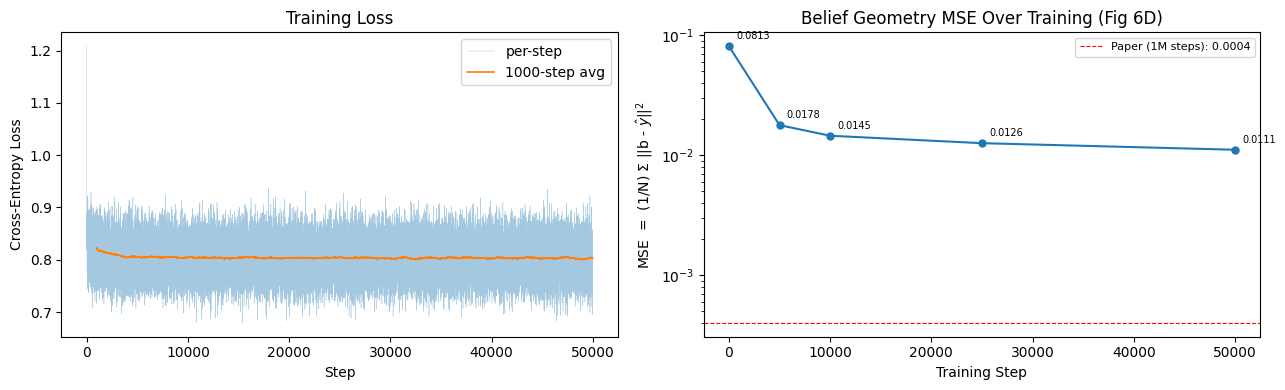

In [6]:
# ── Training loss curve ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(losses, lw=0.3, alpha=0.4, label='per-step')
window = min(1000, len(losses) // 5) if len(losses) > 10 else 1
if window > 1:
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, window-1+len(smoothed)), smoothed, lw=1.2, label=f'{window}-step avg')
ax.set_xlabel('Step')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training Loss')
ax.legend()

# ── Paper MSE over training (Figure 6D) ──
ax = axes[1]
steps_list = sorted(checkpoint_results.keys())
mse_list = [checkpoint_results[s]['paper_mse'] for s in steps_list]
ax.plot(steps_list, mse_list, 'o-', markersize=5)
ax.set_xlabel('Training Step')
ax.set_ylabel('MSE  =  (1/N) $\\Sigma$ ||b - $\\hat{y}$||$^2$')
ax.set_title('Belief Geometry MSE Over Training (Fig 6D)')
ax.set_yscale('log')
for s, m in zip(steps_list, mse_list):
    ax.annotate(f'{m:.4f}', (s, m), textcoords='offset points',
                xytext=(5, 5), fontsize=7)
# Paper reference line: MSE = 0.0004 at 1M steps
ax.axhline(0.0004, color='red', ls='--', lw=0.8, label='Paper (1M steps): 0.0004')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Activation Analysis — Reproducing Figure 5

Extract residual stream activations from the final layer, run weighted linear
regression to find the affine map from activations to belief states, and plot
the result in the probability simplex alongside the ground truth.

In [7]:
# ── Final analysis on the trained model ──
final_scalars, final_arrays, final_acts_flat = run_analysis(return_acts=True)

predicted = np.array(final_arrays['projected'])
gt_beliefs = np.array(final_arrays['targets'])

print('=== Final Model Activation Analysis ===')
print(f"  Paper MSE:    {final_scalars['paper_mse']:.6f}   (paper at 1M steps: ~0.0004)")
print(f"  R-squared:    {final_scalars['r2']:.6f}")
print(f"  Data points:  {n_data:,}   (all {n_all_seqs:,} sequences x {N_CTX} positions)")
print(f"  Activation dim: {D_MODEL}")

# ── Compare with paper ──
paper_ref = 0.0004  # Figure S1: MSE before LayerNorm at 1M steps
our_mse = final_scalars['paper_mse']
print(f'\n--- Comparison with paper ---')
print(f'  Paper MSE (1M steps, Fig S1): {paper_ref}')
print(f'  Our MSE   ({NUM_STEPS//1000}K steps):       {our_mse:.6f}')
if our_mse < paper_ref:
    print(f'  Our MSE is LOWER than paper (unexpected at fewer steps; may improve with more training)')
elif our_mse < paper_ref * 5:
    print(f'  Our MSE is {our_mse/paper_ref:.1f}x the paper value (expected: we trained {1_000_000//NUM_STEPS}x fewer steps)')
else:
    print(f'  Our MSE is {our_mse/paper_ref:.1f}x the paper value. Try increasing NUM_STEPS.')

=== Final Model Activation Analysis ===
  Paper MSE:    0.011065   (paper at 1M steps: ~0.0004)
  R-squared:    0.966817
  Data points:  590,490   (all 59,049 sequences x 10 positions)
  Activation dim: 64

--- Comparison with paper ---
  Paper MSE (1M steps, Fig S1): 0.0004
  Our MSE   (50K steps):       0.011065
  Our MSE is 27.7x the paper value. Try increasing NUM_STEPS.


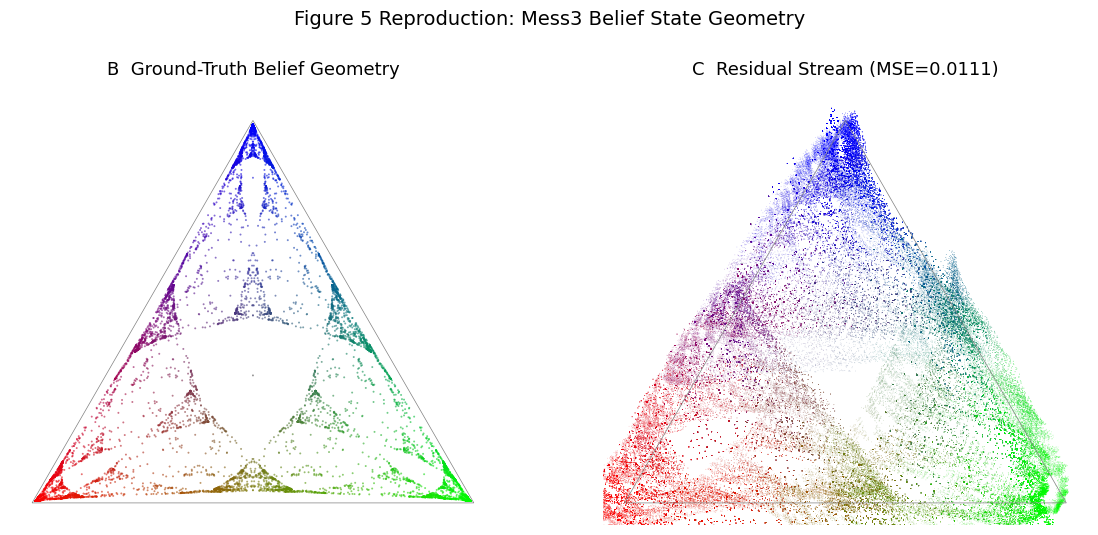

In [8]:
# ── Reproduce Figure 5: side-by-side comparison ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# (B) Ground-truth belief state geometry from MSP
plot_simplex(belief_states_gt,
             'B  Ground-Truth Belief Geometry',
             axes[0], s=2, alpha=0.6)

# (C) Linear projection of residual stream activations
# Color predicted beliefs by the ground-truth belief state (as in paper)
plot_simplex(predicted,
             f"C  Residual Stream (MSE={final_scalars['paper_mse']:.4f})",
             axes[1], colors=gt_beliefs, s=0.3, alpha=0.3)

fig.suptitle('Figure 5 Reproduction: Mess3 Belief State Geometry', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Controls (Figure 6B–D)

- **Cross-validation**: 20% train / 80% test (paper Sec 3.1), repeated 100 times.
  Paper uses 1000 iterations; 100 is sufficient to check consistency.
- **Shuffle**: Randomly permute belief-state-to-activation pairings, 100 times.
  Destroys genuine structure; MSE should be much higher (~0.01, per Figure 6D).

Cross-validation:   0%|          | 0/100 [00:00<?, ?it/s]

Cross-validation:   1%|          | 1/100 [00:00<01:32,  1.07it/s]

Cross-validation:   2%|▏         | 2/100 [00:01<00:51,  1.90it/s]

Cross-validation:   3%|▎         | 3/100 [00:01<00:37,  2.61it/s]

Cross-validation:   4%|▍         | 4/100 [00:01<00:30,  3.18it/s]

...

Shuffle:  98%|█████████▊| 98/100 [01:18<00:01,  1.29it/s]

Shuffle:  99%|█████████▉| 99/100 [01:19<00:00,  1.32it/s]

Shuffle: 100%|██████████| 100/100 [01:20<00:00,  1.32it/s]

Shuffle: 100%|██████████| 100/100 [01:20<00:00,  1.24it/s]


=== Control Results (paper MSE metric) ===
Full regression MSE:   0.011065   (paper Fig S1: ~0.0004)
Cross-val test MSE:    0.004065 +/- 0.000009
Cross-val train MSE:   0.004060 +/- 0.000016
Shuffle MSE:           0.334040 +/- 0.000002   (paper Fig 6D: ~0.01)

CV test / Full ratio:    0.4x   (paper: ~1x)
Shuffle / Full ratio:    30.2x   (paper: ~25x)


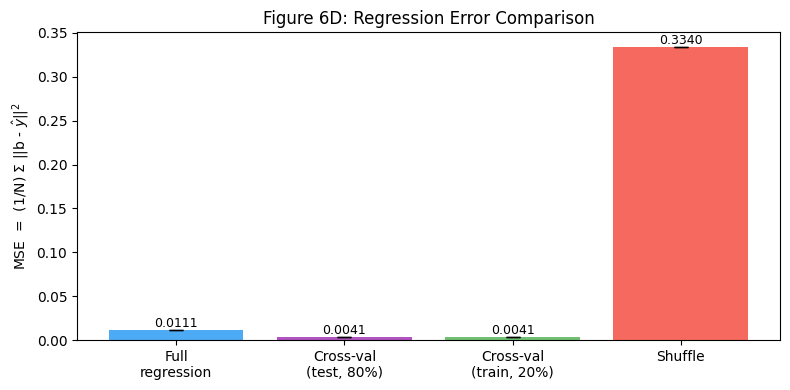

In [9]:
# ── Controls: cross-validation and shuffle (Figure 6B-D) ──
# Uses the same data as final analysis: all sequences, uniform weights, paper MSE.
N = n_data
N_TRIALS = 100  # paper uses 1000

# ── Cross-validation: 20% train, 80% test (paper Sec 3.1) ──
rng = np.random.default_rng(SEED)
cv_test_mses, cv_train_mses = [], []
for _ in tqdm(range(N_TRIALS), desc='Cross-validation'):
    idx = rng.permutation(N)
    n_train = int(0.2 * N)
    train_idx, test_idx = idx[:n_train], idx[n_train:]

    tw = jnp.ones(n_train, dtype=jnp.float32) / n_train
    _, tr_arrays = linear_regression(
        jnp.array(final_acts_flat[train_idx]),
        jnp.array(beliefs_flat[train_idx]),
        tw,
    )
    # Evaluate on held-out 80%
    beta = jnp.concatenate([tr_arrays['intercept'], tr_arrays['coeffs']], axis=0)
    test_x = jnp.concatenate(
        [jnp.ones((len(test_idx), 1)), jnp.array(final_acts_flat[test_idx])], axis=1
    )
    test_pred = np.array(test_x @ beta)
    test_resid = test_pred - beliefs_flat[test_idx]
    cv_test_mses.append(float(np.mean(np.sum(test_resid**2, axis=1))))

    train_resid = np.array(tr_arrays['projected']) - np.array(tr_arrays['targets'])
    cv_train_mses.append(float(np.mean(np.sum(train_resid**2, axis=1))))

# ── Shuffle control (Figure 6C-D) ──
shuffle_mses = []
uniform_w = jnp.ones(N, dtype=jnp.float32) / N
for _ in tqdm(range(N_TRIALS), desc='Shuffle'):
    perm = rng.permutation(N)
    _, sh_arrays = linear_regression(
        jnp.array(final_acts_flat), jnp.array(beliefs_flat[perm]), uniform_w,
    )
    sh_resid = np.array(sh_arrays['projected']) - np.array(sh_arrays['targets'])
    shuffle_mses.append(float(np.mean(np.sum(sh_resid**2, axis=1))))

# ── Report ──
print('\n=== Control Results (paper MSE metric) ===')
print(f'Full regression MSE:   {final_scalars["paper_mse"]:.6f}   (paper Fig S1: ~0.0004)')
print(f'Cross-val test MSE:    {np.mean(cv_test_mses):.6f} +/- {np.std(cv_test_mses):.6f}')
print(f'Cross-val train MSE:   {np.mean(cv_train_mses):.6f} +/- {np.std(cv_train_mses):.6f}')
print(f'Shuffle MSE:           {np.mean(shuffle_mses):.6f} +/- {np.std(shuffle_mses):.6f}   (paper Fig 6D: ~0.01)')

cv_ratio = np.mean(cv_test_mses) / max(final_scalars['paper_mse'], 1e-10)
sh_ratio = np.mean(shuffle_mses) / max(final_scalars['paper_mse'], 1e-10)
print(f'\nCV test / Full ratio:    {cv_ratio:.1f}x   (paper: ~1x)')
print(f'Shuffle / Full ratio:    {sh_ratio:.1f}x   (paper: ~25x)')

# ── Plot (Figure 6D style) ──
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Full\nregression', 'Cross-val\n(test, 80%)', 'Cross-val\n(train, 20%)', 'Shuffle']
means = [final_scalars['paper_mse'], np.mean(cv_test_mses),
         np.mean(cv_train_mses), np.mean(shuffle_mses)]
stds = [0, np.std(cv_test_mses), np.std(cv_train_mses), np.std(shuffle_mses)]
colors_bar = ['#2196F3', '#9C27B0', '#4CAF50', '#F44336']
bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors_bar, alpha=0.8)
ax.set_ylabel('MSE  =  (1/N) $\\Sigma$ ||b - $\\hat{y}$||$^2$')
ax.set_title('Figure 6D: Regression Error Comparison')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()